In [ ]:
import os
import numpy as np
import keras
from keras import layers, models, optimizers
import matplotlib.pyplot as plt
import tensorflow as tf

# Dataset path
dataset_path = '/content/drive/MyDrive/concave'

# Hyperparameters
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001

# VGG16 Model Architecture
def create_vgg16(input_shape=(150,150, 3), num_classes=2):
    model = models.Sequential(name='VGG16')

    # Block 1
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='block1_conv1'))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='block1_conv2'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block2_conv1'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block2_conv2'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block3_conv1'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block3_conv2'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block3_conv3'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

    # Block 4
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block4_conv1'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block4_conv2'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block4_conv3'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))

    # Block 5
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block5_conv1'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block5_conv2'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block5_conv3'))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'))

    # Fully Connected Layers
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(512, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.5, name='dropout1'))
    model.add(layers.Dense(512, activation='relu', name='fc2'))
    model.add(layers.Dropout(0.5, name='dropout2'))
    model.add(layers.Dense(num_classes, activation='softmax', name='predictions'))

    return model

# Data Augmentation Layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Load Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Load Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Get number of classes and class names
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Normalize pixel values to [0, 1]
normalization_layer = layers.Rescaling(1./255)

# Apply normalization and augmentation
train_ds = train_ds.map(lambda x, y: (data_augmentation(normalization_layer(x), training=True), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimize performance with prefetching
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Create Model
model = create_vgg16(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes)

# Compile Model
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'vgg16_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train Model
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

# Plot Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

# Save Final Model
model.save('vgg16_final_model.keras')
print("\nModel training complete and saved!")

# Print class mapping
print(f"\nClass mapping: {dict(enumerate(class_names))}")

Found 900 files belonging to 6 classes.
Using 720 files for training.
Found 900 files belonging to 6 classes.
Using 180 files for validation.
Number of classes: 6
Class names: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,043,558 (23.05 MB)

 Trainable params: 6,043,558 (23.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


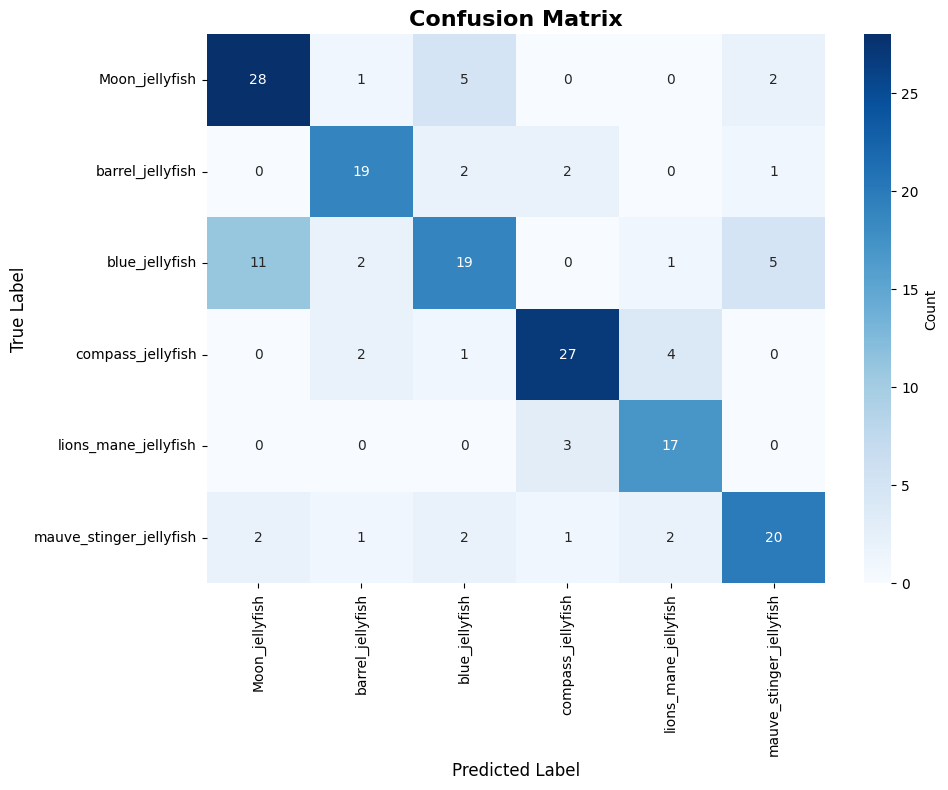


CLASSIFICATION REPORT
                         precision    recall  f1-score   support

         Moon_jellyfish     0.6829    0.7778    0.7273        36
       barrel_jellyfish     0.7600    0.7917    0.7755        24
         blue_jellyfish     0.6552    0.5000    0.5672        38
      compass_jellyfish     0.8182    0.7941    0.8060        34
   lions_mane_jellyfish     0.7083    0.8500    0.7727        20
mauve_stinger_jellyfish     0.7143    0.7143    0.7143        28

               accuracy                         0.7222       180
              macro avg     0.7232    0.7380    0.7272       180
           weighted avg     0.7206    0.7222    0.7178       180


DETAILED METRICS PER CLASS

Moon_jellyfish:
  Total samples: 36
  Correctly classified: 28
  Accuracy: 0.7778 (77.78%)

barrel_jellyfish:
  Total samples: 24
  Correctly classified: 19
  Accuracy: 0.7917 (79.17%)

blue_jellyfish:
  Total samples: 38
  Correctly classified: 19
  Accuracy: 0.5000 (50.00%)

compass_jellyfish

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on validation set (using the model already in memory)
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Calculate and display additional metrics
print("\n" + "="*60)
print("DETAILED METRICS PER CLASS")
print("="*60)

for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    total = np.sum(class_mask)
    correct = np.sum((y_true == i) & (y_pred == i))
    accuracy = correct / total if total > 0 else 0

    print(f"\n{class_name}:")
    print(f"  Total samples: {total}")
    print(f"  Correctly classified: {correct}")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Overall Accuracy
overall_accuracy = np.sum(y_true == y_pred) / len(y_true)
print("\n" + "="*60)
print(f"OVERALL ACCURACY: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print("="*60)